<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:


# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


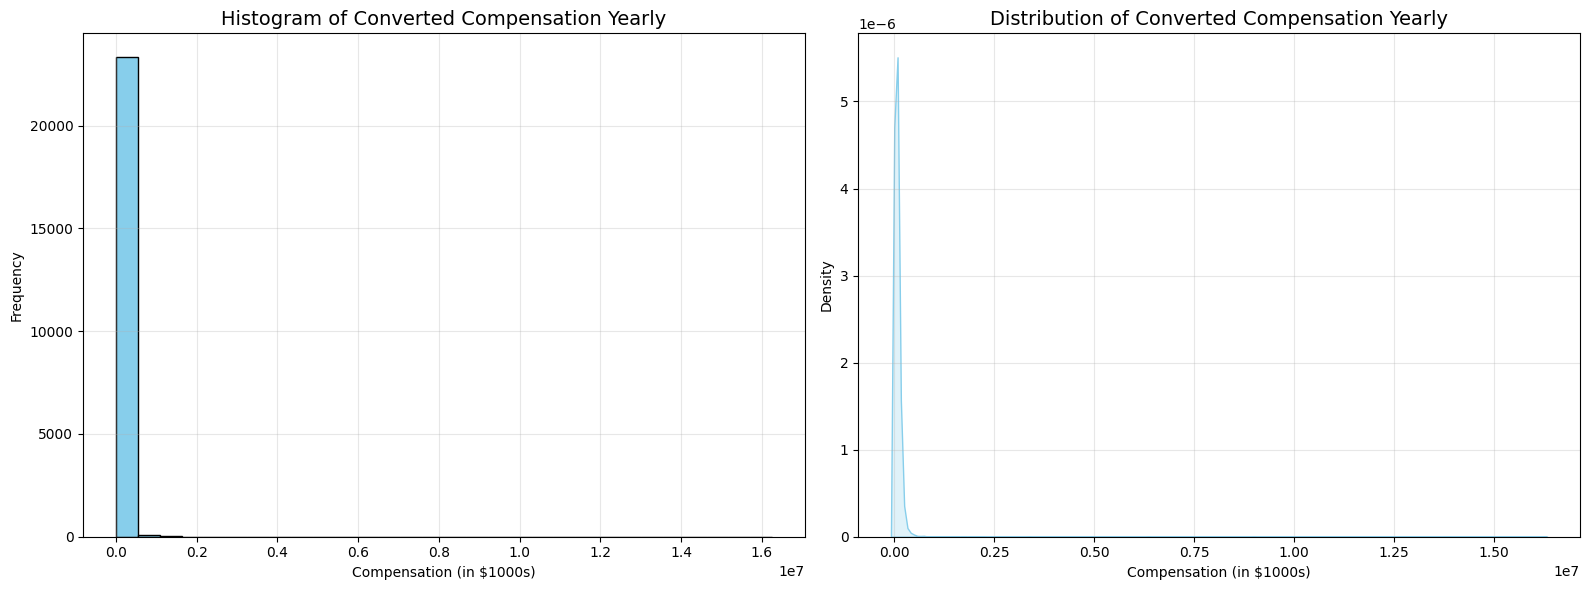

In [48]:
# ... existing code from previous steps ...

# Step 3: Analyze and Visualize Compensation Distribution
# Create two subplots: Histogram and Distribution (Density) Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Histogram showing frequency distribution
axes[0].hist(df['ConvertedCompYearly'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Converted Compensation Yearly', fontsize=14)
axes[0].set_xlabel('Compensation (in $1000s)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Distribution (Density/KDE) Plot showing the shape of distribution
sns.kdeplot(df['ConvertedCompYearly'], ax=axes[1], fill=True, color='skyblue')
axes[1].set_title('Distribution of Converted Compensation Yearly', fontsize=14)
axes[1].set_xlabel('Compensation (in $1000s)')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [10]:
# ... existing code from previous steps ...

# Step 4: Calculate Median Compensation for Full-Time Employees
full_time = df[df['Employment'] == 'Employed, full-time']
median_compensation = full_time['ConvertedCompYearly'].median()

print(f'Median compensation for full‑time employees: ${median_compensation:,.0f}')

Median compensation for full‑time employees: $69,814


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



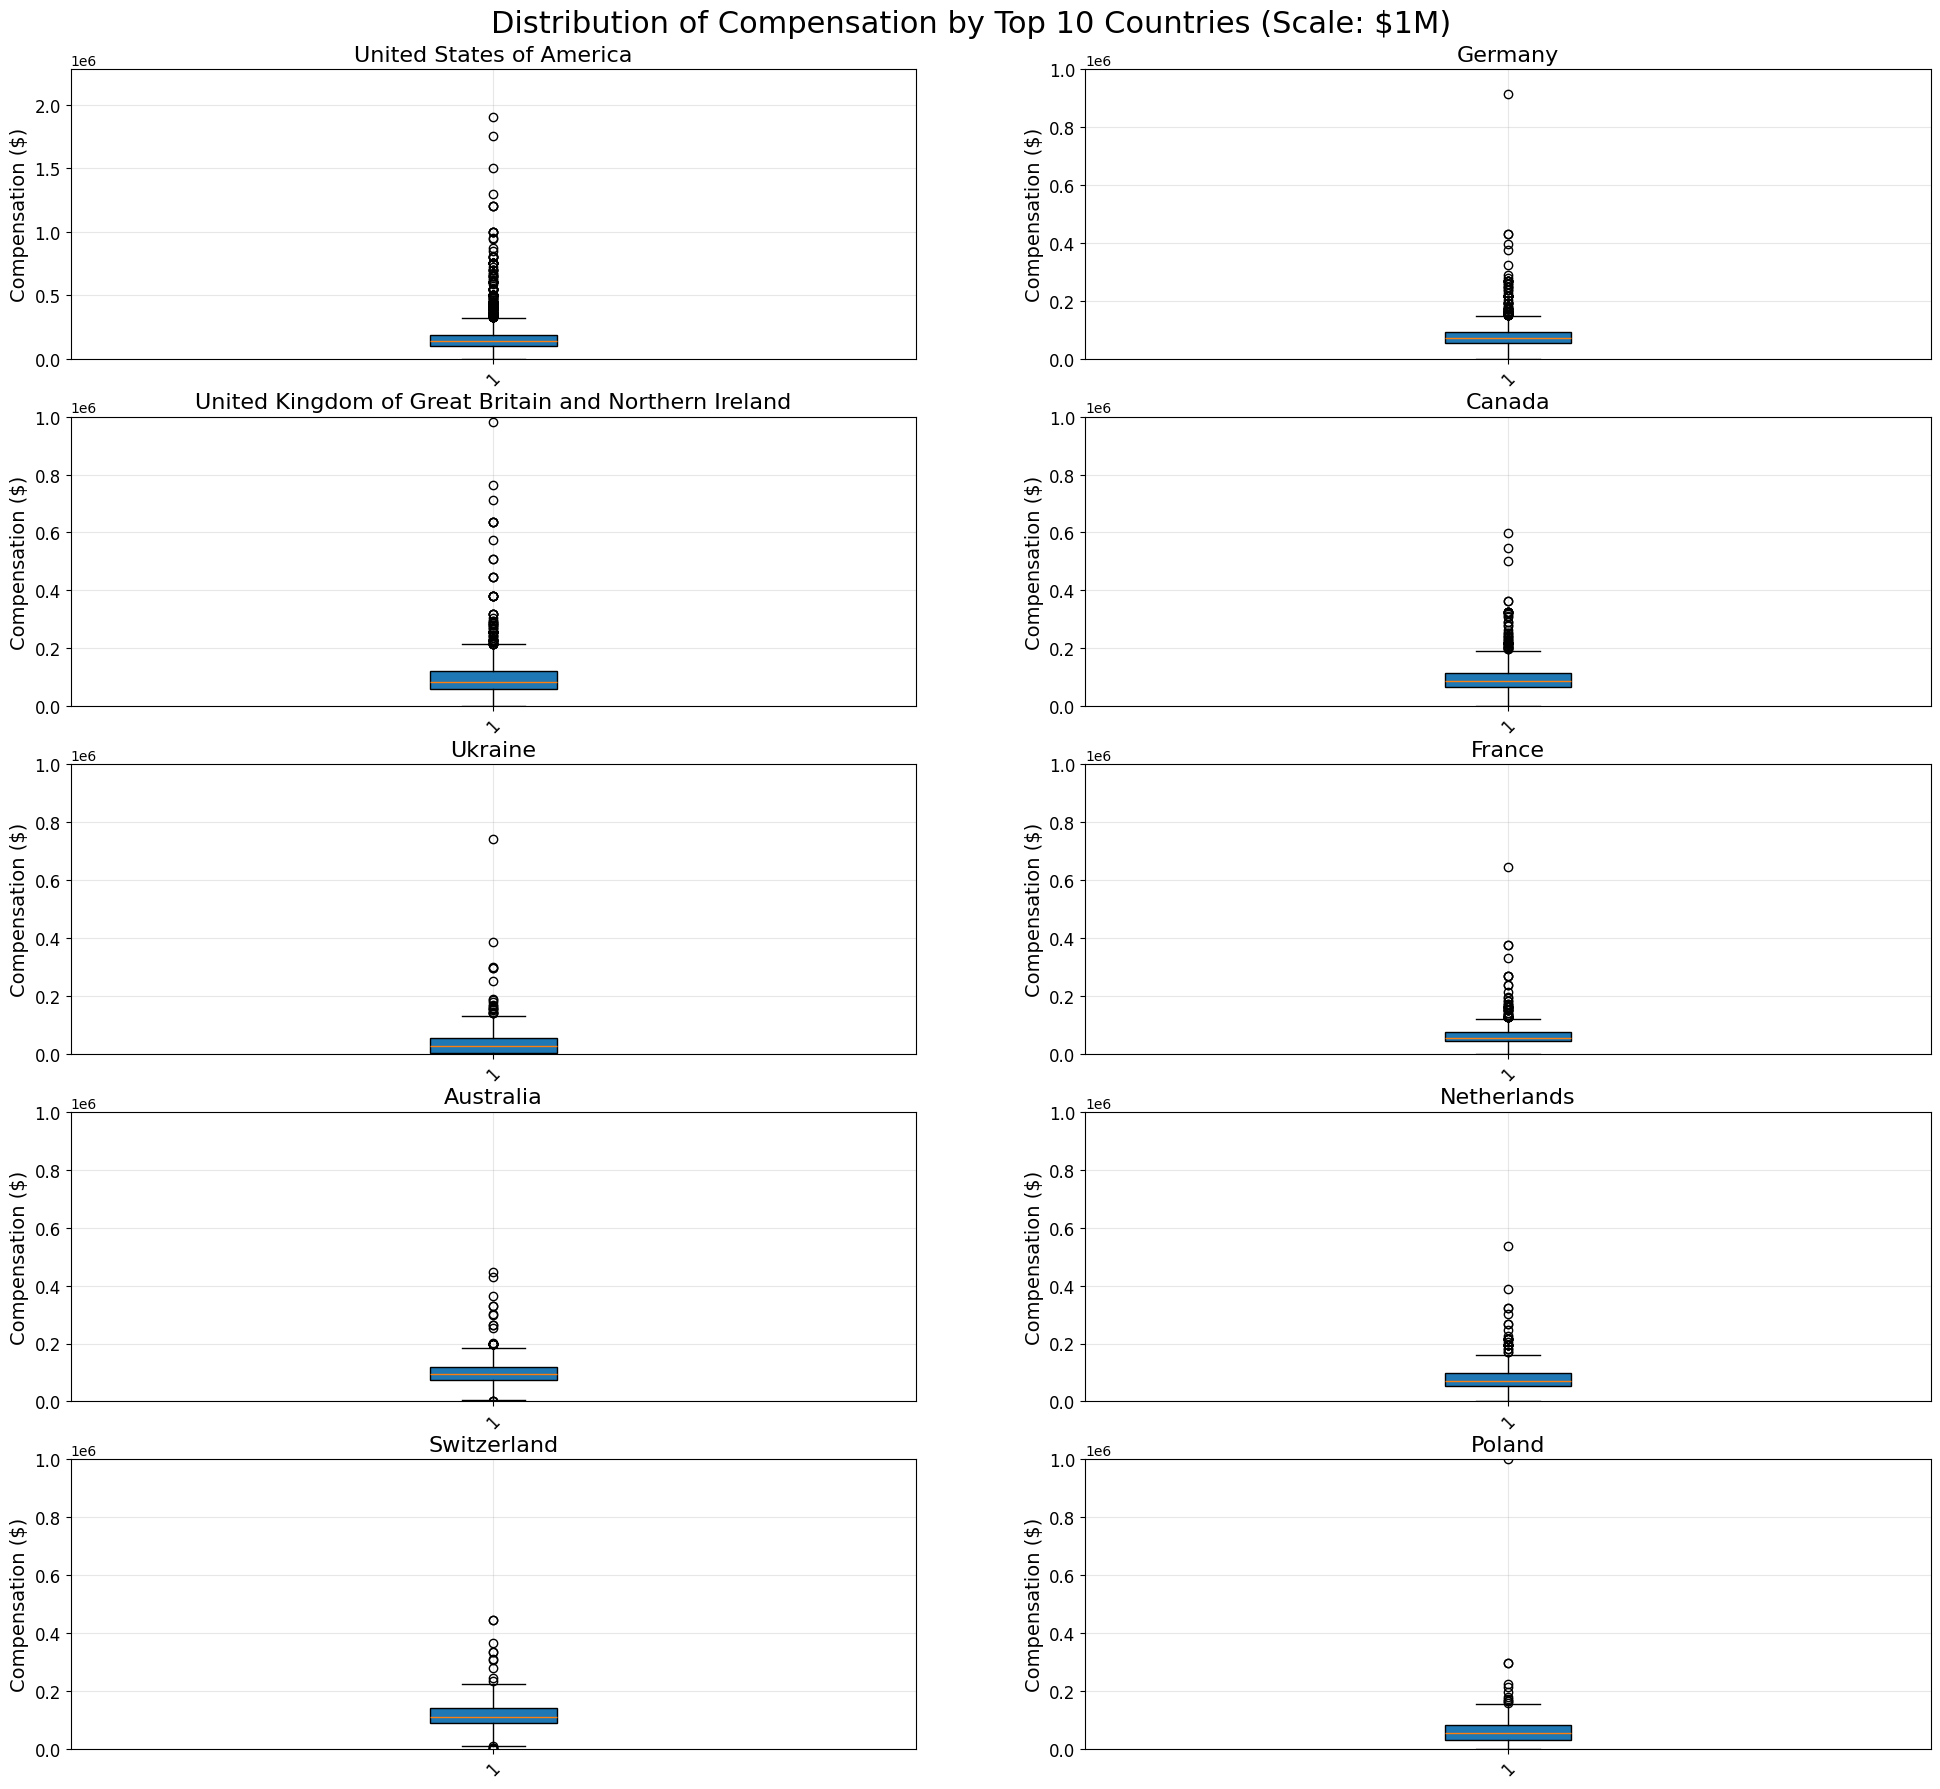

In [43]:
# ... existing code from previous steps ...

# Step 5: Analyze Top 10 Countries by Total Compensation (US Outlier Fix)
# Clean Country column (remove extra spaces)
df['Country'] = df['Country'].str.strip()

# Remove rows where ConvertedCompYearly is missing (NaN)
df_clean = df.dropna(subset=['ConvertedCompYearly'])

# Get top 10 countries by TOTAL compensation (Sum)
top_10_countries = df_clean.groupby('Country')['ConvertedCompYearly'].sum().nlargest(10).reset_index(name='Total Comp')

# Create a figure with 2 columns and 5 rows for 10 graphs
fig, axes = plt.subplots(5, 2, figsize=(24, 20))
axes = axes.flatten()  # Flatten to make indexing easier

# Plot each country's data
for i, (idx, row) in enumerate(top_10_countries.iterrows()):
    country_name = row['Country']
    # Filter data for this specific country
    subset = df_clean[df_clean['Country'] == country_name]['ConvertedCompYearly']
    
    # Check if there is data before plotting
    if len(subset) > 0:
        axes[i].boxplot(subset, patch_artist=True)
        # Increased font sizes for better readability
        axes[i].set_title(f'{country_name}', fontsize=16)
        axes[i].set_ylabel('Compensation ($)', fontsize=14)
        
        # Dynamic Y-axis limit for US to show outliers clearly
        if country_name == 'United States of America':
            max_val = subset.max()
            axes[i].set_ylim(0, max_val * 1.2) # 20% headroom
        else:
            axes[i].set_ylim(0, 1000000) 
        
        axes[i].grid(True, alpha=0.3)
        # Increased tick label size
        axes[i].tick_params(axis='x', rotation=45, labelsize=12)
        axes[i].tick_params(axis='y', labelsize=12)
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[i].transAxes)

# Removed tight_layout() to allow subplots_adjust to work properly
plt.subplots_adjust(top=0.95) 
plt.suptitle('Distribution of Compensation by Top 10 Countries (Scale: $1M)', fontsize=22)
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [44]:
## Write your code here
# ... existing code from previous steps ...

# Step 6: Removing Outliers from the Dataset
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a new DataFrame without outliers
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

# Display the shape to show how many rows were removed
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after removing outliers: {df_no_outliers.shape}")

Original dataset shape: (65437, 114)
Dataset shape after removing outliers: (22457, 114)


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


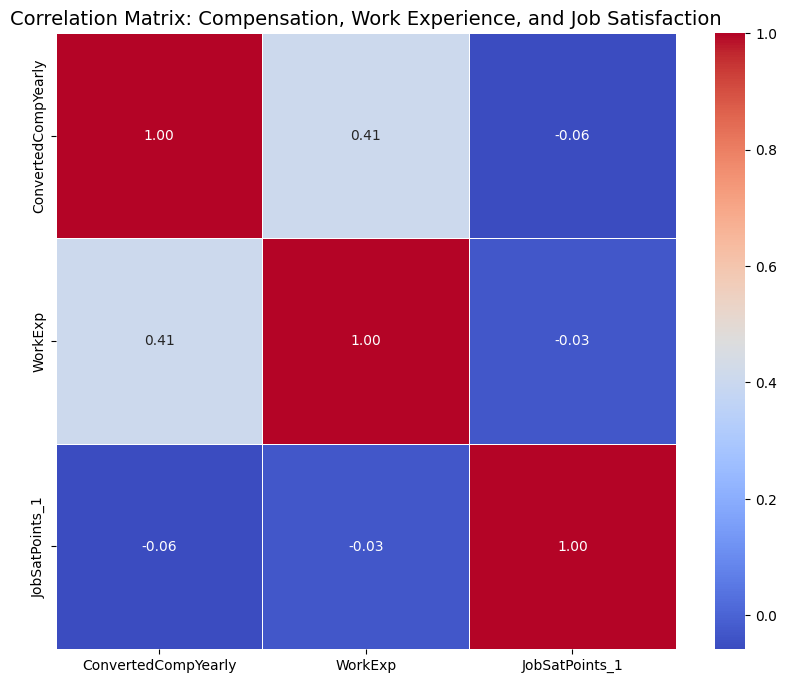

In [46]:
## Write your code here
# ... existing code from previous steps ...

# Step 7: Finding Correlations Between Key Variables
# Select the relevant columns
correlation_data = df_no_outliers[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Visualize the correlations with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: Compensation, Work Experience, and Job Satisfaction', fontsize=14)
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


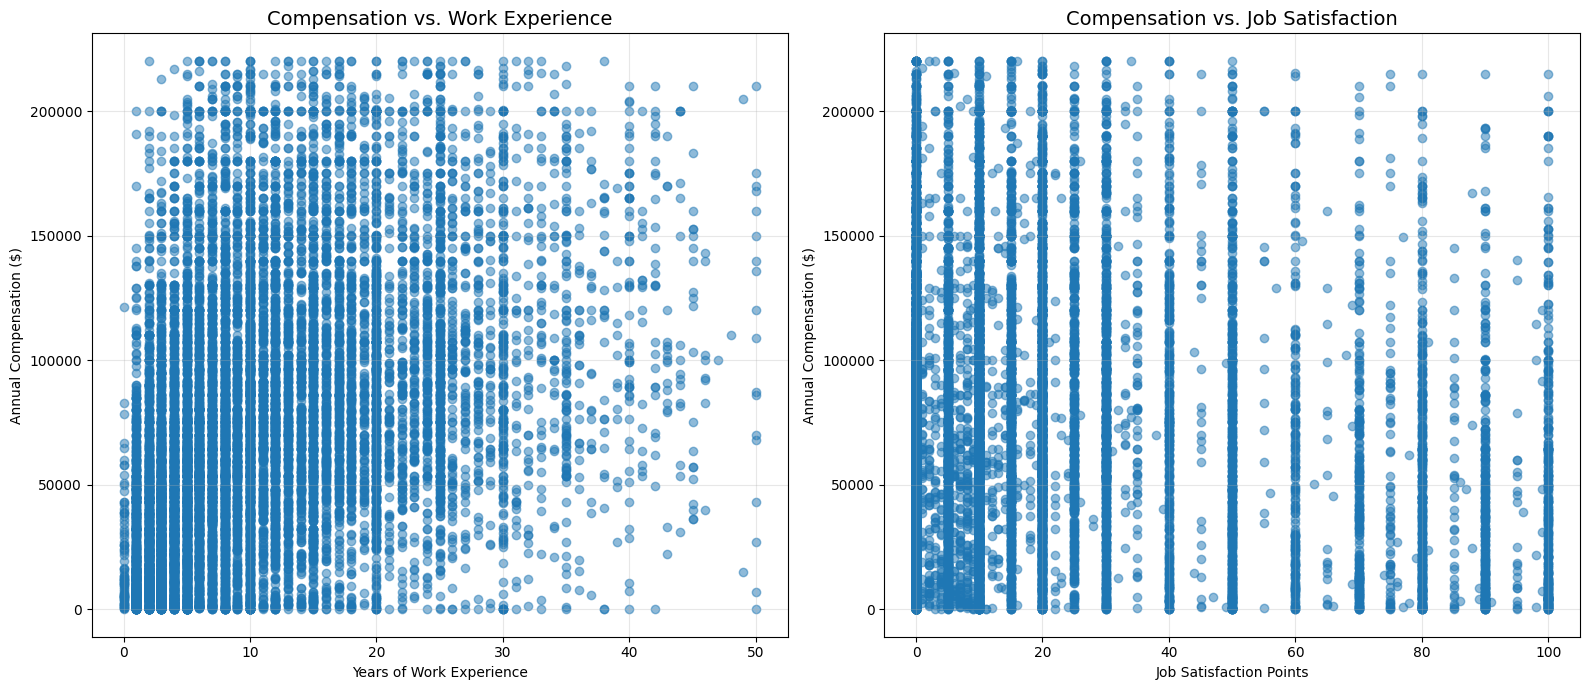

In [47]:
## Write your code here
# ... existing code from previous steps ...

# Step 8: Scatter Plot for Correlations
# Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot 1: ConvertedCompYearly vs. WorkExp
axes[0].scatter(df_no_outliers['WorkExp'], df_no_outliers['ConvertedCompYearly'], alpha=0.5)
axes[0].set_title('Compensation vs. Work Experience', fontsize=14)
axes[0].set_xlabel('Years of Work Experience')
axes[0].set_ylabel('Annual Compensation ($)')
axes[0].grid(True, alpha=0.3)

# Scatter plot 2: ConvertedCompYearly vs. JobSatPoints_1
axes[1].scatter(df_no_outliers['JobSatPoints_1'], df_no_outliers['ConvertedCompYearly'], alpha=0.5)
axes[1].set_title('Compensation vs. Job Satisfaction', fontsize=14)
axes[1].set_xlabel('Job Satisfaction Points')
axes[1].set_ylabel('Annual Compensation ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
